# LeetCode #117: Populating Next Right Pointers in Each Node II

https://leetcode.com/problems/populating-next-right-pointers-in-each-node-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS with Queue | O(n) | O(n) | Uses extra queue memory |
| **Dummy Head Level Walk** | **O(n)** | **O(1)** | **Optimal — uses existing .next links** |

## Understanding the Method

We traverse each level using the already-established `.next` pointers from the previous pass.
A dummy head node is used to build the next level's linked list without tracking index bookkeeping.

- `curr` walks the current level via `.next`
- A `dummy` + `tail` pair builds the next level's chain
- Works for any binary tree (not just perfect trees)

## Constraints

- Number of nodes: `[0, 6000]`
- `-100 <= Node.val <= 100`
- Use only **O(1)** extra space (no queue allowed)

## Solutions

### C#

In [ ]:
public class Solution {
    public Node Connect(Node root) {
        Node curr = root;
        while (curr != null) {
            Node dummy = new Node(0);
            Node tail = dummy;
            while (curr != null) {
                if (curr.left != null) { tail.next = curr.left; tail = tail.next; }
                if (curr.right != null) { tail.next = curr.right; tail = tail.next; }
                curr = curr.next;
            }
            curr = dummy.next;
        }
        return root;
    }
}

### Python

In [ ]:
class Solution:
    def connect(self, root: 'Node') -> 'Node':
        curr = root
        while curr:
            dummy = Node(0)
            tail = dummy
            while curr:
                if curr.left:
                    tail.next = curr.left
                    tail = tail.next
                if curr.right:
                    tail.next = curr.right
                    tail = tail.next
                curr = curr.next
            curr = dummy.next
        return root

### Go

In [ ]:
func connect(root *Node) *Node {
    curr := root
    for curr != nil {
        dummy := &Node{}
        tail := dummy
        for curr != nil {
            if curr.Left != nil {
                tail.Next = curr.Left
                tail = tail.Next
            }
            if curr.Right != nil {
                tail.Next = curr.Right
                tail = tail.Next
            }
            curr = curr.Next
        }
        curr = dummy.Next
    }
    return root
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn connect(root: Option<Rc<RefCell<Node>>>) -> Option<Rc<RefCell<Node>>> {
        let mut curr = root.clone();
        while let Some(node) = curr {
            let dummy = Rc::new(RefCell::new(Node::new(0)));
            let mut tail = Rc::clone(&dummy);
            let mut c = Some(Rc::clone(&node));
            while let Some(n) = c {
                let left = n.borrow().left.clone();
                let right = n.borrow().right.clone();
                if let Some(l) = left {
                    tail.borrow_mut().next = Some(Rc::clone(&l));
                    tail = Rc::clone(&l);
                }
                if let Some(r) = right {
                    tail.borrow_mut().next = Some(Rc::clone(&r));
                    tail = Rc::clone(&r);
                }
                c = n.borrow().next.clone();
            }
            curr = dummy.borrow().next.clone();
        }
        root
    }
}

## Example Scenarios

### 1. Common Case — Non-Perfect Tree [1,2,3,4,5,null,7]
**Input:** `root = [1, 2, 3, 4, 5, null, 7]`

Level 0: `curr = 1`, children 2 and 3 $\Rightarrow$ chain: $2 \to 3 \to \text{NULL}$. Level 1: `curr = 2` has children 4, 5. `curr = 3` has no left, right = 7. Chain: $4 \to 5 \to 7 \to \text{NULL}$. Node 5 links directly to 7, skipping the absent node 6.

*Why tricky:* Node 3 has no left child, so 5.next skips directly to 7. The dummy head approach handles missing children without index tracking.

**Output:** `[1,#,2,3,#,4,5,7,#]`

### 2. Slightly Complex — Sparse Tree with Gaps at Multiple Levels
**Input:** `root = [1, 2, 3, 4, null, null, 5, null, null, 6, null]`

Level 1: chain $2 \to 3$. Level 2: node 2 has left=4 (no right), node 3 has right=5 (no left). Chain: $4 \to 5$ (skipping 2 absent nodes). Level 3: only node 5 has child 6. Chain: $6 \to \text{NULL}$.

*Why tricky:* Multiple missing children at different levels. The dummy-head builds correct chains regardless of which children exist.

**Output:** `4.next = 5 (skipping absent siblings)`

### 3. Edge Case: Time Factor — 6000-Node Left-Skewed Chain
**Input:** Left-only chain of $n = 6000$ nodes (max constraint)

6000 levels, one node per level. Outer loop runs 6000 times. Inner loop runs once per level (single `curr`). Each node's `.next = \text{NULL}$ (only node at its level). Total $O(n) = O(6000)$.

*Why tricky:* Maximum nodes in worst-case depth. Each level has exactly one node, so next is always NULL. Tests 6000 outer-loop iterations.

**Output:** `Every node.next = NULL`

### 4. Edge Case: Space Factor — Wide Tree (BFS Needs O(n/2) Queue)
**Input:** Complete binary tree, $n = 6000$, depth $\approx 12$, widest level $\approx 3000$ nodes

BFS would need a queue of $\sim 3000$ entries at the widest level. Dummy-head level walk uses only 3 pointer variables (`dummy`, `tail`, `curr`). Total space $= O(1)$.

*Why tricky:* Demonstrates $3000\times$ space savings over BFS. The dummy-head reuses established `.next` pointers to traverse each level.

**Output:** `O(1) space vs O(n/2) for BFS`

### 5. Almost-Impossible but Plausible — Zigzag (Alternating Left/Right)
**Input:** `root = [1, null, 2, 3, null, null, 4, 5, null]` (zigzag shape)

Children alternate left/right at each level: $1 \to \text{right}(2) \to \text{left}(3) \to \text{right}(4) \to \text{left}(5)$. Each level has one node. The dummy-head handles left-only and right-only parents uniformly.

*Why tricky:* Zigzag shape tests both `if curr.left` and `if curr.right` branches alternating at each level. Every node's `.next = \text{NULL}$ since each level has only one child.

**Output:** `Each node.next = NULL (zigzag shape, one node per level)`

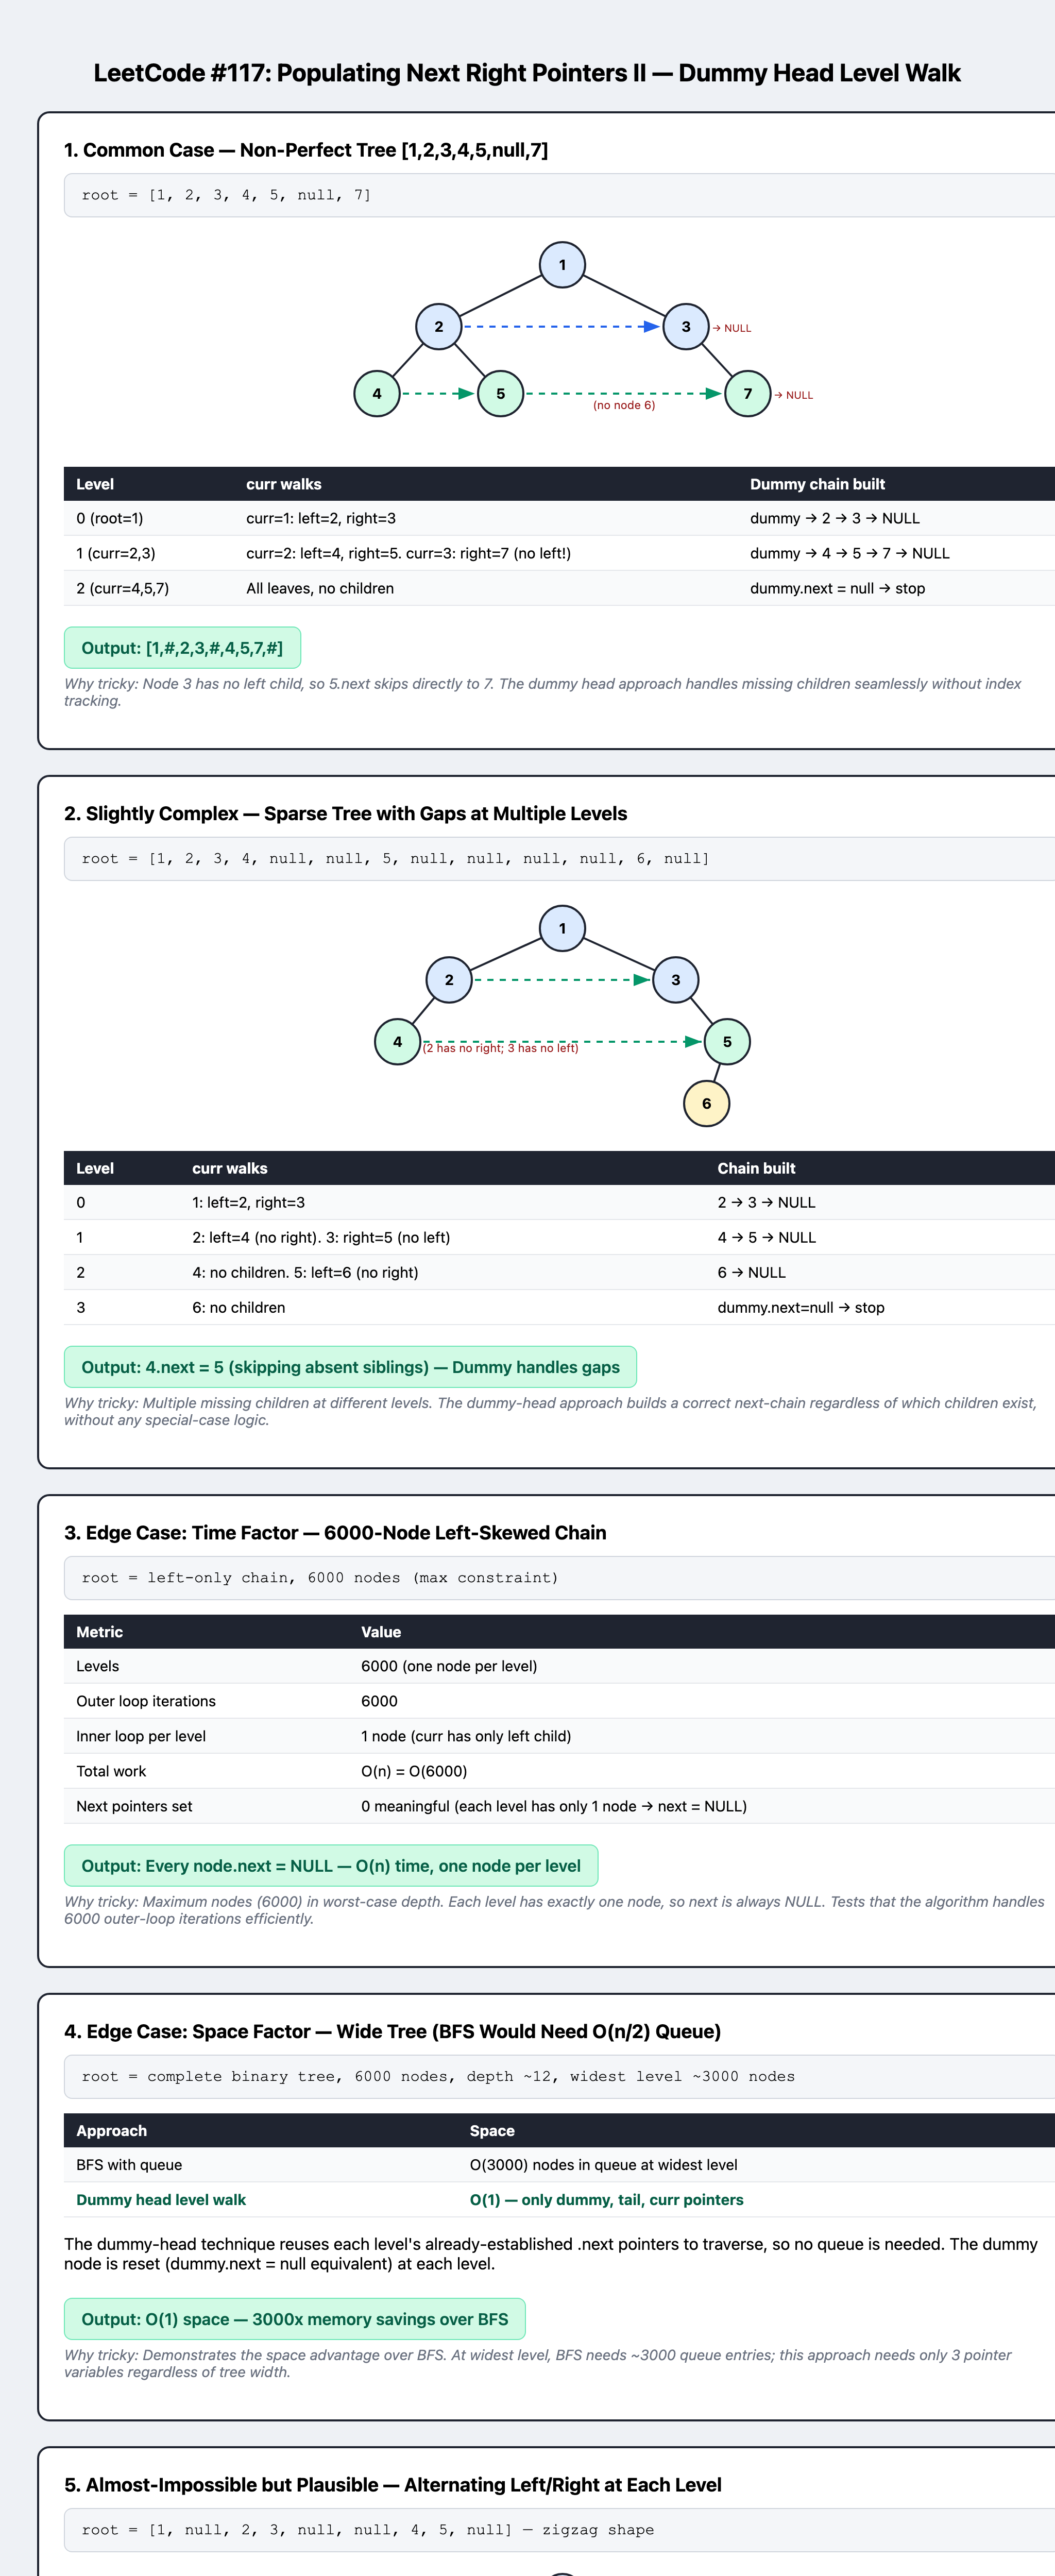